In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [7]:
iris = load_iris()
X = iris.data[ : , : 2] # takes 2 features only
y = iris.target

In [8]:
mask = y < 2 # keep only 0,1 class
X = X[mask]
y = y[mask]

In [9]:
 # Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(80, 2)

In [12]:
# paramters of SVC 
"""
C -> regularlization term. controls trade-off between bias-variance. 
     Low c -> wider margin, more misclassifications allowed (better generalization, less overfitting).
     High C → narrower margin, fewer misclassifications (risk of overfitting).
"""

""" 
kernel: kernel function
  linear -> straight hyperplane, good for high-dimensional data(text). 
  rbf -> Gaussian kernel, most common non-linear problems.
  poly -> polynomial kernel. degree(only used for poly) value controls the complexity. Higher degree -> chance of overfitting.
  sigmoid -> behaves like neural net.
"""

"""
gamma -> defines the influence of a single row. 
small value -> smoother boundary
"""

""" 
tol: stopping tolerance for optimization. small value more precise optimization. Slow down the speed.
"""
""" 
class_weight: handle imbalance class issue.
"""

""" 
decision_function_shape: multi-class. 
'ovr': One-vs-Rest.
'ovo': One-vs-One.
"""

" \ndecision_function_shape: multi-class. \n'ovr': One-vs-Rest.\n'ovo': One-vs-One.\n"

In [13]:
svm = SVC(kernel = 'rbf' , C = 1 , gamma = 'scale')
svm.fit(X_train , y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
# Plot decision boundary
def plot_decision_boundary(clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], 
                s=100, facecolors='none', edgecolors='k', label='Support Vectors')
    plt.title(title)
    plt.legend()

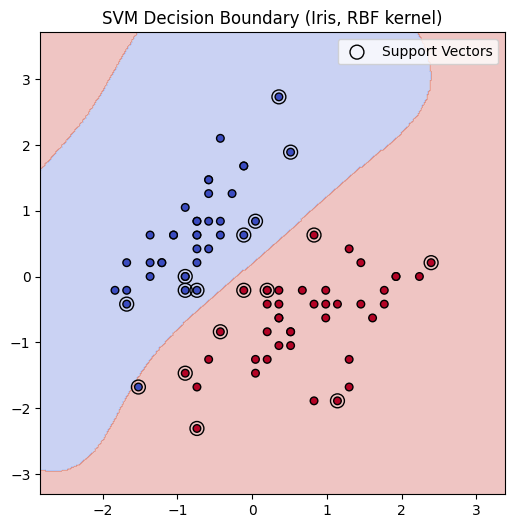

In [15]:
plt.figure(figsize=(6, 6))
plot_decision_boundary(svm, X_train, y_train, "SVM Decision Boundary (Iris, RBF kernel)")
plt.show()